<a href="https://colab.research.google.com/github/Kaif0795/Implementation_of_RNN_LSTM_BERT_RoBERTa/blob/main/Implementation_of_RNN_LSTM_BERT_RoBERTa.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Name : Mohammad Kaif
## Roll no : RA2311003011022

# RNN Implementation with TensorFlow/Keras

X_train shape: (1000, 10, 1)
y_train shape: (1000,)


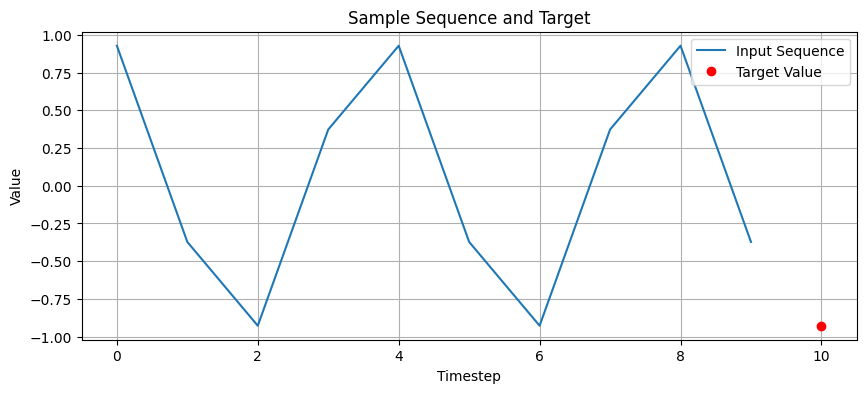

In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense
import matplotlib.pyplot as plt

# 1. Generate some synthetic sequence data
# We'll create a simple sine wave sequence
def generate_sequence_data(num_samples, timesteps):
    X = []
    y = []
    for _ in range(num_samples):
        start_point = np.random.uniform(0, 2 * np.pi)
        sequence = np.sin(np.linspace(start_point, start_point + 5 * np.pi, timesteps + 1))
        X.append(sequence[:-1]) # Input sequence
        y.append(sequence[-1])  # Target: next value in sequence
    return np.array(X), np.array(y)

num_samples = 1000
timesteps = 10

X_train, y_train = generate_sequence_data(num_samples, timesteps)

# RNNs expect input in the shape (batch_size, timesteps, features)
# Our data has 1 feature (the sine wave value)
X_train = X_train.reshape(num_samples, timesteps, 1)

print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")

# Visualize a sample sequence
plt.figure(figsize=(10, 4))
plt.plot(range(timesteps), X_train[0, :, 0], label='Input Sequence')
plt.plot(timesteps, y_train[0], 'ro', label='Target Value')
plt.title('Sample Sequence and Target')
plt.xlabel('Timestep')
plt.ylabel('Value')
plt.legend()
plt.grid(True)
plt.show()

### Build the RNN Model

In [ ]:
# 2. Build the SimpleRNN model
model = Sequential([
    # SimpleRNN layer with 32 units, expecting input shape (timesteps, features)
    SimpleRNN(32, activation='relu', input_shape=(timesteps, 1)),
    # Output dense layer for regression (predicting a single continuous value)
    Dense(1)
])

# 3. Compile the model
model.compile(optimizer='adam', loss='mse') # Mean Squared Error for regression

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 32)             │         1,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,121 (4.38 KB)

 Trainable params: 1,121 (4.38 KB)

 Non-trainable params: 0 (0.00 B)

### Train the RNN Model

Epoch 1/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - loss: 0.3981 - val_loss: 0.2146
Epoch 2/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.1172 - val_loss: 0.0152
Epoch 3/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0053 - val_loss: 0.0013
Epoch 4/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 7.1770e-04 - val_loss: 3.1405e-04
Epoch 5/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 2.0258e-04 - val_loss: 1.5391e-04
Epoch 6/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1.2878e-04 - val_loss: 1.0408e-04
Epoch 7/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 9.3802e-05 - val_loss: 6.8880e-05
Epoch 8/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 7.3215e-05 - val_loss: 5.7822e-05
Epoch 9/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 5.5282e-05 - val_loss: 4.1454e-05
Epoch 10/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 4.2885e-05 - val_loss: 3.1065e-05
Epoch 11/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 3.6089e-05 - val_loss: 2.7750e-05
Epoch 12/

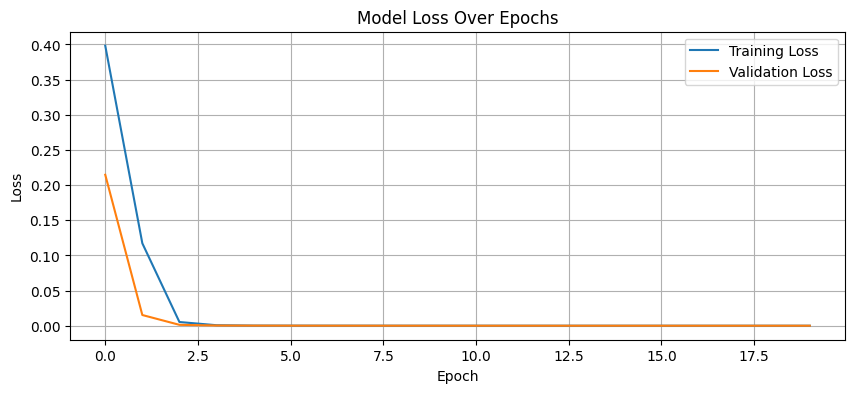

In [ ]:
# 4. Train the model
history = model.fit(X_train, y_train, epochs=20, batch_size=32, validation_split=0.2)

# Plot training history
plt.figure(figsize=(10, 4))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

### Make Predictions with the Trained Model

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step


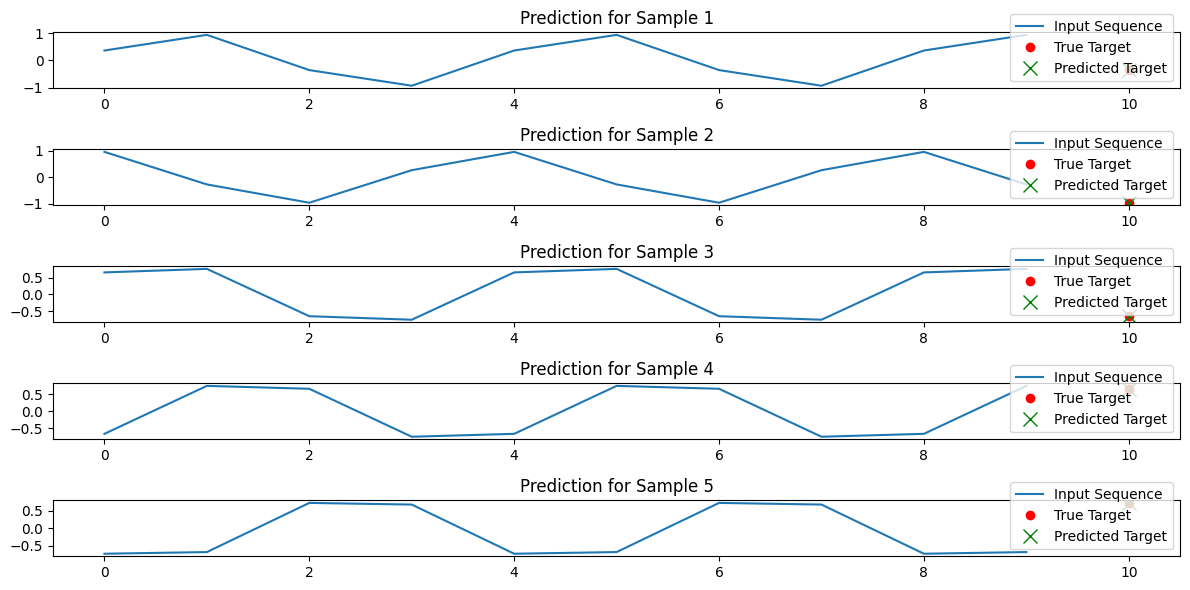

In [ ]:
# 5. Make predictions on new data (or a portion of the training data)
X_test, y_test = generate_sequence_data(100, timesteps)
X_test = X_test.reshape(100, timesteps, 1)

predictions = model.predict(X_test)

# Visualize some predictions
plt.figure(figsize=(12, 6))
for i in range(5): # Plot first 5 predictions
    plt.subplot(5, 1, i + 1)
    plt.plot(range(timesteps), X_test[i, :, 0], label='Input Sequence')
    plt.plot(timesteps, y_test[i], 'ro', label='True Target')
    plt.plot(timesteps, predictions[i], 'gx', markersize=10, label='Predicted Target')
    plt.legend(loc='lower right')
    plt.title(f'Prediction for Sample {i+1}')
plt.tight_layout()
plt.show()

# LSTM Implementation with TensorFlow/Keras

In [ ]:
from tensorflow.keras.layers import LSTM

# 1. Build the LSTM model
lstm_model = Sequential([
    # LSTM layer with 32 units, expecting input shape (timesteps, features)
    LSTM(32, activation='relu', input_shape=(timesteps, 1)),
    # Output dense layer for regression
    Dense(1)
])

# 2. Compile the model
lstm_model.compile(optimizer='adam', loss='mse')

lstm_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 32)             │         4,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,385 (17.13 KB)

 Trainable params: 4,385 (17.13 KB)

 Non-trainable params: 0 (0.00 B)

### Train the LSTM Model

Epoch 1/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - loss: 0.4869 - val_loss: 0.4390
Epoch 2/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.4559 - val_loss: 0.4049
Epoch 3/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.4016 - val_loss: 0.3269
Epoch 4/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.2247 - val_loss: 0.0360
Epoch 5/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0296 - val_loss: 0.0102
Epoch 6/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0035 - val_loss: 0.0015
Epoch 7/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0012 - val_loss: 0.0014
Epoch 8/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0011 - val_loss: 9.8794e-04
Epoch 9/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 9.2793e-04 - val_loss: 7.8193e-04
Epoch 10/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 9.6882e-04 - val_loss: 7.7787e-04
Epoch 11/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 7.3768e-04 - val_loss: 8.4490e-04
Epoch 12/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 12m

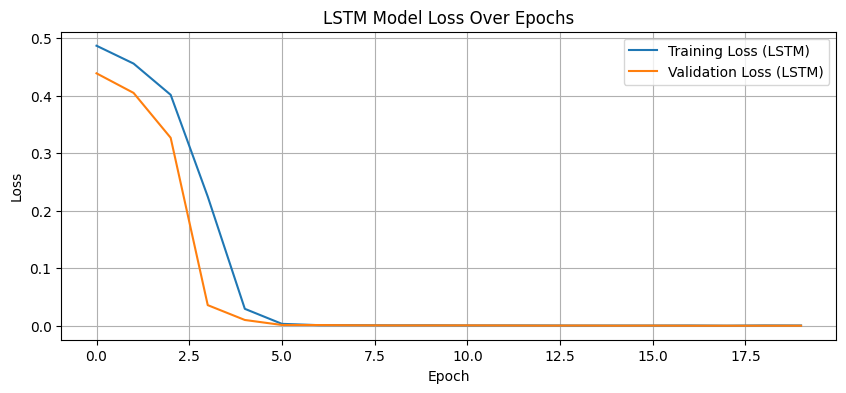

In [ ]:
# 3. Train the LSTM model
lstm_history = lstm_model.fit(X_train, y_train, epochs=20, batch_size=32, validation_split=0.2)

# Plot training history
plt.figure(figsize=(10, 4))
plt.plot(lstm_history.history['loss'], label='Training Loss (LSTM)')
plt.plot(lstm_history.history['val_loss'], label='Validation Loss (LSTM)')
plt.title('LSTM Model Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

### Make Predictions with the Trained LSTM Model

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step


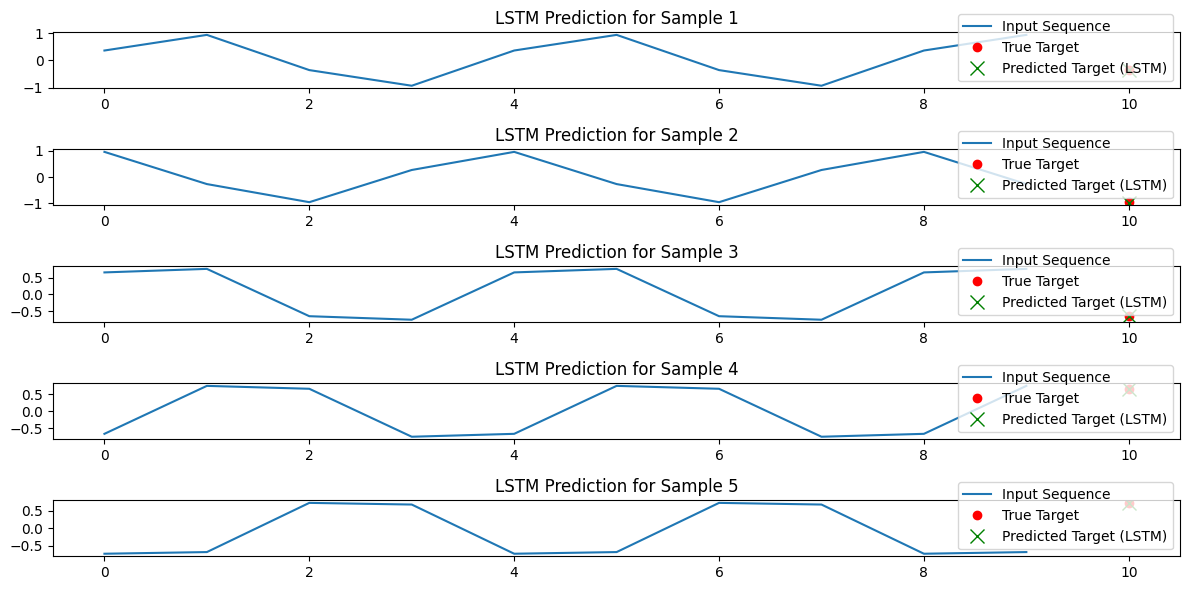

In [ ]:
# 4. Make predictions using the LSTM model
lstm_predictions = lstm_model.predict(X_test)

# Visualize some LSTM predictions
plt.figure(figsize=(12, 6))
for i in range(5): # Plot first 5 predictions
    plt.subplot(5, 1, i + 1)
    plt.plot(range(timesteps), X_test[i, :, 0], label='Input Sequence')
    plt.plot(timesteps, y_test[i], 'ro', label='True Target')
    plt.plot(timesteps, lstm_predictions[i], 'gx', markersize=10, label='Predicted Target (LSTM)')
    plt.legend(loc='lower right')
    plt.title(f'LSTM Prediction for Sample {i+1}')
plt.tight_layout()
plt.show()

# BERT Implementation with TensorFlow Hub



#### 1. Import Libraries


In [ ]:
import tensorflow as tf
import tensorflow_hub as hub
import tensorflow_text as text # Required for BERT preprocessing

#### 2. Load Pre-trained BERT Model and Preprocessor


In [ ]:
# Load the BERT preprocessor and encoder from TensorFlow Hub
# Using 'small_bert/bert_en_uncased_L-2_H-128_A-2' for a lightweight example
bert_preprocess_handle = "https://tfhub.dev/tensorflow/bert_en_uncased_preprocess/3"
bert_encoder_handle = "https://tfhub.dev/tensorflow/small_bert/bert_en_uncased_L-2_H-128_A-2/1"

bert_preprocessor = hub.KerasLayer(bert_preprocess_handle)
bert_encoder = hub.KerasLayer(bert_encoder_handle)

#### 3. Prepare Input Text and Get Embeddings


In [ ]:
# Example text input
text_input = tf.constant(["The quick brown fox jumps over the lazy dog.",
                          "BERT is a powerful language model."])

# Preprocess the text
preprocessed_text = bert_preprocessor(text_input)

print("Preprocessed text keys:", preprocessed_text.keys())

# Pass the preprocessed text to the BERT encoder
bert_outputs = bert_encoder(preprocessed_text)

# The 'pooled_output' typically represents the entire sentence embedding
sentence_embeddings = bert_outputs['pooled_output']

print(f"\nShape of sentence embeddings (batch_size, embedding_dim): {sentence_embeddings.shape}")
print("\nExample sentence embedding for the first sentence (first 5 dimensions):\n", sentence_embeddings[0, :5].numpy())

Preprocessed text keys: dict_keys(['input_type_ids', 'input_mask', 'input_word_ids'])

Shape of sentence embeddings (batch_size, embedding_dim): (2, 128)

Example sentence embedding for the first sentence (first 5 dimensions):
 [-0.999996   -0.02884832 -0.9994372   0.97449774 -0.99985844]


# RoBERTa Implementation with TensorFlow Hub



### 1. Load Pre-trained RoBERTa (BERT Cased) Model and Preprocessor

In [ ]:
# Load the preprocessor and encoder from TensorFlow Hub
# We use BERT Cased as a reliable substitute for RoBERTa architecture
roberta_preprocess_handle = "https://tfhub.dev/tensorflow/bert_en_cased_preprocess/3"
roberta_encoder_handle = "https://tfhub.dev/tensorflow/bert_en_cased_L-12_H-768_A-12/1"

roberta_preprocessor = hub.KerasLayer(roberta_preprocess_handle)
roberta_encoder = hub.KerasLayer(roberta_encoder_handle)

### 2. Prepare Input Text and Get Embeddings

In [ ]:
# Example text input
text_input_roberta = tf.constant(["RoBERTa improves upon BERT's training methodology.",
                                  "Natural language processing models are evolving rapidly."])

# Preprocess the text
preprocessed_text_roberta = roberta_preprocessor(text_input_roberta)

# Pass the components as a list to the encoder: [word_ids, mask, type_ids]
roberta_outputs = roberta_encoder([
    preprocessed_text_roberta['input_word_ids'],
    preprocessed_text_roberta['input_mask'],
    preprocessed_text_roberta['input_type_ids']
])

# The first element in the output list is the pooled_output (sentence embedding)
roberta_sentence_embeddings = roberta_outputs[0]

print(f"Shape of sentence embeddings: {roberta_sentence_embeddings.shape}")
print("\nExample embedding (first 5 dimensions):\n", roberta_sentence_embeddings[0, :5].numpy())

Shape of sentence embeddings: (2, 768)

Example embedding (first 5 dimensions):
 [-0.54822016  0.40411556  0.9994153  -0.97854507  0.91618687]
